# Лабораторная работа 2. Обучение с учителем. Задача регрессии

**Содержание** <a id='toc_0'></a>
- [1. Загрузка и подготовка данных](#toc_1)
    - [1.1. Загрузка датасета](#toc_1_1)
    - [1.2. Выделение целевого признака и предикторов](#toc_1_2)
    - [1.3. Разбиение на обучающую и тестовую выборки](#toc_1_3)
- [2. Решение задач регрессии](#toc_2)
    - [2.1. Простая линейная регрессия](#toc_2_1)
    - [2.2. L1](#toc_2_2)
    - [2.3. L2](#toc_2_3)
    - [2.4. ElasticNet (линейная регрессия с двумя регуляризаторами](#toc_2_4)
    - [2.5. Полиноминальная регрессия](#toc_2_5)
    - [2.6. Собственный линейный регрессор](#toc_2_6)
- [3. Поиск оптимального гиперпараметра для моделей](#toc_3)
    - [3.1. GridSearchCV](#toc_3_1)
    - [3.2. RandomizedSearchCV](#toc_3_2)
    - [3.3. Optuna](#toc_3_3)
- [4. Построение Pipelines](#toc_4)
- [5. Собственные метрики](#toc_5)
- [6. Вывод](#toc_6)

In [1]:
import pandas as pd

## <a id='toc_1'></a>[1. Загрузка и подготовка данных](#toc_0)

### <a id='toc_1_1'></a>[1.1. Загрузка датасета](#toc_0)

In [2]:
data = pd.read_csv('../datasets/filtered_moldova_cars_task.csv')
data

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro),Vehicle_age,Avg_mileage
0,67,467,2011,4,195000,1800,2,0,7750,15,13000
1,55,315,2014,11,135000,1500,0,1,8550,12,11250
2,55,370,2012,11,110000,1500,0,1,6550,14,7857
3,51,123,2006,11,200000,1600,3,1,4100,20,10000
4,45,629,2000,5,300000,2200,0,1,3490,26,11538
...,...,...,...,...,...,...,...,...,...,...,...
27132,70,447,2016,10,88000,1800,4,0,11500,10,8800
27133,39,288,2002,3,225000,1800,3,1,4400,24,9375
27134,16,382,2015,11,89000,1500,0,1,7000,11,8091
27135,44,72,2006,1,370000,2000,0,1,4000,20,18500


### <a id='toc_1_2'></a>[1.2. Выделение целевого признака и предикторов](#toc_0)

In [3]:
y = data["Price(euro)"]
X = data.drop(["Price(euro)"], axis=1)

In [4]:
y

0         7750
1         8550
2         6550
3         4100
4         3490
         ...  
27132    11500
27133     4400
27134     7000
27135     4000
27136     4000
Name: Price(euro), Length: 27137, dtype: int64

In [5]:
X

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Vehicle_age,Avg_mileage
0,67,467,2011,4,195000,1800,2,0,15,13000
1,55,315,2014,11,135000,1500,0,1,12,11250
2,55,370,2012,11,110000,1500,0,1,14,7857
3,51,123,2006,11,200000,1600,3,1,20,10000
4,45,629,2000,5,300000,2200,0,1,26,11538
...,...,...,...,...,...,...,...,...,...,...
27132,70,447,2016,10,88000,1800,4,0,10,8800
27133,39,288,2002,3,225000,1800,3,1,24,9375
27134,16,382,2015,11,89000,1500,0,1,11,8091
27135,44,72,2006,1,370000,2000,0,1,20,18500


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### <a id='toc_1_3'></a>[1.3. Разбиение на обучающую и тестовую выборки](#toc_0)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((21709, 10), (21709,), (5428, 10), (5428,))

## <a id='toc_2'></a>[2. Решение задачи регрессии](#toc_0)

In [9]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from math import sqrt

### <a id='toc_2_1'></a>[2.1. Простая линейная регрессия](#toc_0)

In [10]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [11]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')
lr.coef_

MAE: 2162.048730621871
MSE: 8513187.47417213
RMSE: 2917.736704051983
MAPE: 0.49558495403760566
R^2: 0.6812711439984207


array([  -19.79552391,    70.01493635,  1165.91583011,  -212.06656954,
       -1657.7164293 ,  1622.57175759,   203.89629584, -1017.29912127,
       -1165.91583011,  1434.37120689])

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

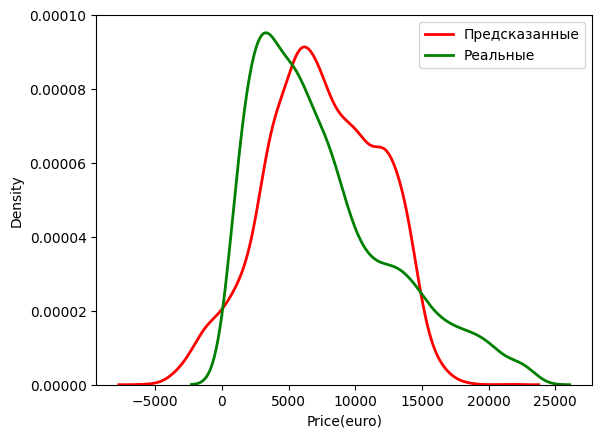

In [13]:
sns.kdeplot(y_pred, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

### <a id='toc_2_2'></a>[2.2. L1](#toc_0)

In [14]:
# L1
lasso = Lasso(alpha=0.5, max_iter=50000).fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred_lasso)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_lasso)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_lasso))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_lasso)}')
print(f'R^2: {r2_score(y_test, y_pred_lasso)}')
lasso.coef_

MAE: 2162.0044323798534
MSE: 8512838.058737362
RMSE: 2917.6768256161204
MAPE: 0.49554731994587276
R^2: 0.6812842259118792


array([  -19.18869192,    69.50591575,  2334.40199528,  -211.46370705,
       -1652.97083612,  1621.63577058,   202.8213554 , -1017.53128139,
          -0.        ,  1429.50410345])

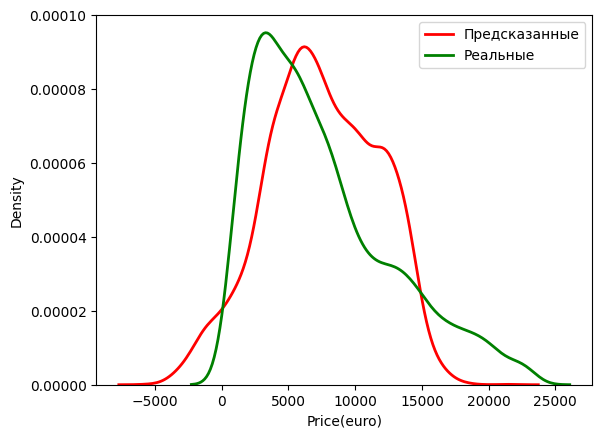

In [15]:
sns.kdeplot(y_pred_lasso, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

### <a id='toc_2_3'></a>[2.3. L2](#toc_0)

In [16]:
# L2
ridge = Ridge(alpha=0.5, max_iter=50000).fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_ridge)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_ridge))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_ridge)}')
print(f'R^2: {r2_score(y_test, y_pred_ridge)}')
ridge.coef_

MAE: 2162.048954144069
MSE: 8513175.226951279
RMSE: 2917.7346052976236
MAPE: 0.4955830105716685
R^2: 0.6812716025273445


array([  -19.79829526,    70.02223518,  1166.01369303,  -212.05133955,
       -1657.35598763,  1622.50237384,   203.85686465, -1017.32048549,
       -1166.01369203,  1434.01952015])

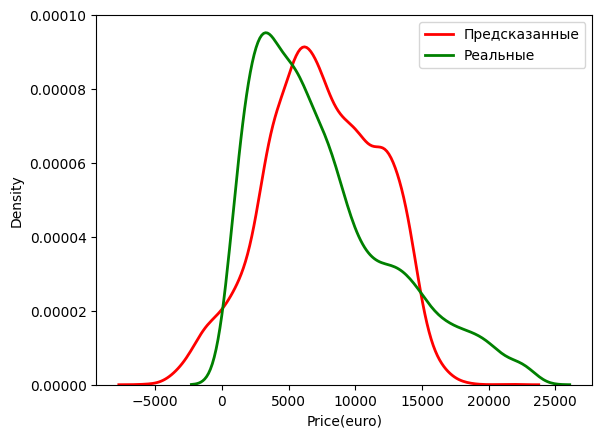

In [17]:
sns.kdeplot(y_pred_ridge, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

### <a id='toc_2_4'></a>[2.4. ElasticNet (линейная регрессия с двумя регуляризаторами)](#toc_0)

In [18]:
el = ElasticNet(alpha=0.5, max_iter=50000).fit(X_train, y_train)
y_pred_el = el.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred_el)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_el)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_el))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_el)}')
print(f'R^2: {r2_score(y_test, y_pred_el)}')
el.coef_

MAE: 2216.7730472618637
MSE: 8918835.569002545
RMSE: 2986.4419580836566
MAPE: 0.4840867235098708
R^2: 0.6660839120013842


array([  -60.37480031,   117.07247666,  1253.19668262,  -145.93077244,
        -767.09817627,  1180.06616906,    20.65286711, -1069.64391274,
       -1253.12133501,   577.65218378])

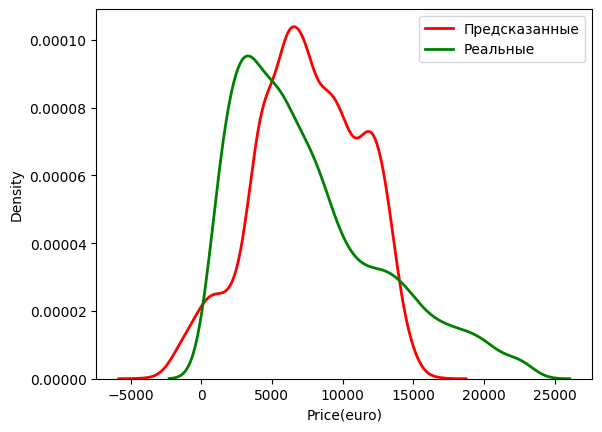

In [19]:
sns.kdeplot(y_pred_el, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

### <a id='toc_2_5'></a>[2.5. Полиноминальная регрессия](#toc_0)

In [20]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train)
X_test_p = poly.transform(X_test)
lr2 = LinearRegression().fit(X_train_p, y_train)
y_pred_p = lr2.predict(X_test_p)
print(f'MAE: {mean_absolute_error(y_test, y_pred_p)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_p)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_p))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_p)}')
print(f'R^2: {r2_score(y_test, y_pred_p)}')
lr2.coef_

MAE: 1674.1694803369317
MSE: 5504067.299727946
RMSE: 2346.0748708700553
MAPE: 0.35025468958067607
R^2: 0.793930877345258


array([ 9.56104503e+01,  5.55569982e+01, -2.56795555e+04, -1.62264307e+02,
       -6.67588292e+04,  1.65017660e+03, -1.06973305e+02, -5.23319953e+02,
        2.56795555e+04,  6.48888544e+04,  8.23213434e+01,  1.34721282e+02,
        7.10260425e-01,  8.55780217e+01,  1.24057180e+02, -2.42137789e+02,
        4.78814395e+00,  2.37400519e+02, -7.10260189e-01, -1.20595800e+02,
        6.96233073e+01,  7.48119307e+01, -9.24320464e+01,  2.35221335e+01,
        1.35845193e+02, -3.27781239e+01,  2.37673813e+01, -7.48119308e+01,
       -6.08447007e+01,  4.14935250e+02, -4.85401328e+01,  2.60204419e+02,
        2.35829223e+02,  2.21815802e+01, -2.13278128e+02, -4.14935250e+02,
       -1.23382330e+04,  3.16515919e+00,  2.20461421e+01, -2.68775649e+01,
        6.42058784e+01,  4.30153733e+01,  4.85401328e+01,  1.50693255e+01,
        2.91635069e+02, -4.13899704e+02,  2.46635839e+02,  6.45337087e+01,
       -2.60204419e+02, -4.17412143e+02, -6.56729199e+01, -1.77926567e+02,
       -1.39970009e+02, -

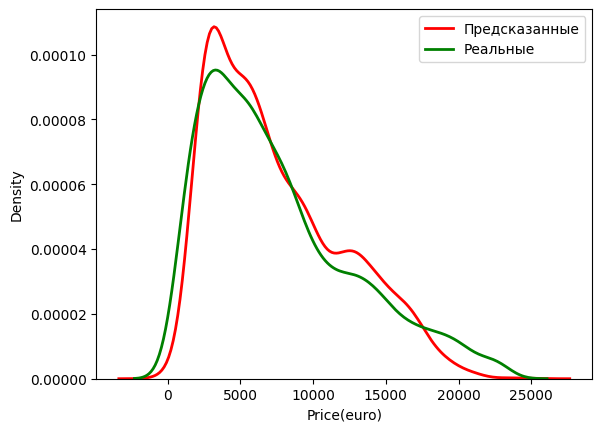

In [21]:
sns.kdeplot(y_pred_p, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

### <a id='toc_2_6'></a>[2.6. Собственный линейный регрессор](#toc_0)

In [22]:
import numpy as np

class CustomRidgeRegression:
    def __init__(self, alpha=1.0, learning_rate=0.001, n_iter=1000, tol=1e-6):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.tol = tol
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        for i in range(self.n_iter):
            y_pred = np.dot(X, self.weights) + self.bias
            errors = y_pred - y
            
            # Градиенты с L2 регуляризацией (исправленный коэффициент)
            dw = (2/n_samples) * np.dot(X.T, errors) + self.alpha * self.weights
            db = (2/n_samples) * np.sum(errors)
            
            # Критерий остановки
            if np.linalg.norm(dw) < self.tol and abs(db) < self.tol:
                print(f'Ранняя остановка на итерации {i}')
                break
            
            # Обновление параметров
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Сохранение loss для анализа
            mse = np.mean(errors**2)
            self.loss_history.append(mse)
            
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    
    def get_coef(self):
        return self.weights, self.bias

In [23]:
custom_ridge = CustomRidgeRegression(alpha=0.5, learning_rate=0.001, n_iter=5000)
custom_ridge.fit(X_train, y_train.values)
y_pred_custom = custom_ridge.predict(X_test)

print("Кастомная Ridge регрессия:")
print(f'R^2: {r2_score(y_test, y_pred_custom):.6f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_custom):.6f}')
print(f'MSE: {mean_squared_error(y_test, y_pred_custom):.6f}')

from sklearn.linear_model import Ridge
sklearn_ridge = Ridge(alpha=0.5)
sklearn_ridge.fit(X_train, y_train)
y_pred_sklearn = sklearn_ridge.predict(X_test)

print("\nSklearn Ridge регрессия:")
print(f'R^2: {r2_score(y_test, y_pred_sklearn):.6f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_sklearn):.6f}')
print(f'MSE: {mean_squared_error(y_test, y_pred_sklearn):.6f}')

Кастомная Ridge регрессия:
R^2: 0.666020
MAE: 2217.081035
MSE: 8920550.120455

Sklearn Ridge регрессия:
R^2: 0.681272
MAE: 2162.048954
MSE: 8513175.226951


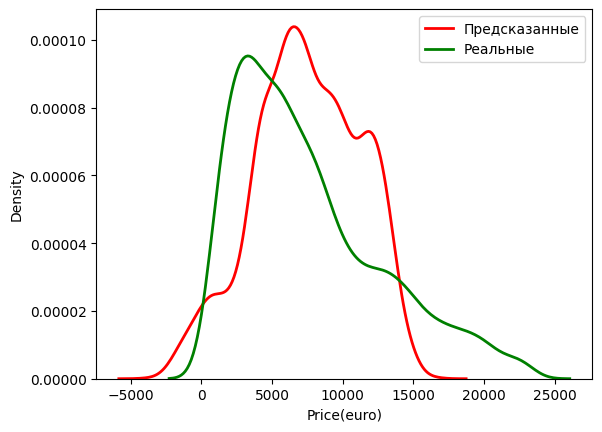

In [24]:
sns.kdeplot(y_pred_custom, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

## <a id='toc_3'></a>[3. Поиск оптимального гиперпараметра для моделей](#toc_0)

In [25]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

In [26]:
parameters = {'alpha': np.arange(0.1, 10.1, 0.1)}
parameters_el = {'alpha': np.arange(0.1, 10.1, 0.1), 'l1_ratio': np.arange(0.1, 1.1, 0.1)}

### <a id='toc_3_1'></a>[3.1. GridSearchCV](#toc_0)

In [27]:
lasso_optimal = GridSearchCV(Lasso(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"\nЛучший параметр для модели Lasso методом GridSearchCV: {lasso_optimal.best_params_}")

ridge_optimal = GridSearchCV(Ridge(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"Лучший параметр для модели Ridge методом GridSearchCV: {ridge_optimal.best_params_}")

el_optimal = GridSearchCV(ElasticNet(max_iter = 10000), parameters_el, cv=5).fit(X_train, y_train)
print(f"Лучший параметр для модели ElasticNet методом GridSearchCV: {el_optimal.best_params_}")


Лучший параметр для модели Lasso методом GridSearchCV: {'alpha': np.float64(0.2)}
Лучший параметр для модели Ridge методом GridSearchCV: {'alpha': np.float64(6.5)}
Лучший параметр для модели ElasticNet методом GridSearchCV: {'alpha': np.float64(0.2), 'l1_ratio': np.float64(1.0)}


### <a id='toc_3_2'></a>[3.2. RandomizedSearchCV](#toc_0)

In [28]:

lasso_optimal = RandomizedSearchCV(Lasso(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"\nЛучший параметр для модели Lasso методом RandomizedSearchCV: {lasso_optimal.best_params_}")

ridge_optimal = RandomizedSearchCV(Ridge(max_iter = 10000), parameters, cv=5).fit(X_train, y_train)
print(f"Лучший параметр для модели Ridge методом RandomizedSearchCV: {ridge_optimal.best_params_}")

el_optimal = RandomizedSearchCV(ElasticNet(max_iter = 10000), parameters_el, cv=5).fit(X_train, y_train)
print(f"Лучший параметр для модели ElasticNet методом RandomizedSearchCV: {el_optimal.best_params_}")


Лучший параметр для модели Lasso методом RandomizedSearchCV: {'alpha': np.float64(0.5)}
Лучший параметр для модели Ridge методом RandomizedSearchCV: {'alpha': np.float64(7.2)}
Лучший параметр для модели ElasticNet методом RandomizedSearchCV: {'l1_ratio': np.float64(1.0), 'alpha': np.float64(1.6)}


### <a id='toc_3_3'></a>[3.3. Optuna](#toc_0)

In [29]:
import optuna as pt

def optuna(model_name, X_train, y_train, X_test, y_test):
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-5, 1e2)

        if model_name == 'lasso':
            model = Lasso(alpha=alpha)
        elif model_name == 'ridge':
            model = Ridge(alpha=alpha)
        elif model_name == 'elasticnet':
            l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        return mse
    
    study = pt.create_study(direction='minimize')
    study.optimize(objective, n_trials=100)

    best_params = study.best_params
    
    return best_params['alpha'] if model_name != 'elasticnet' else (best_params['alpha'], best_params['l1_ratio'])


/home/alexey-rau/projects/omgtu/OMGTU/2year/4semester/MLDA/.venv_mlda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
models = ('lasso', 'ridge', 'elasticnet')
best_params = {}

for model in models:
    best_param = optuna(model, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    best_params[f'{model}_optuna'] = best_param

[I 2026-02-25 23:31:37,352] A new study created in memory with name: no-name-202ecd84-96a6-4c65-99be-cdc39904d272
[I 2026-02-25 23:31:37,367] Trial 0 finished with value: 8509402.083434941 and parameters: {'alpha': 6.77089898454354}. Best is trial 0 with value: 8509402.083434941.
[I 2026-02-25 23:31:37,377] Trial 1 finished with value: 8522983.387415864 and parameters: {'alpha': 42.10297572055432}. Best is trial 0 with value: 8509402.083434941.
[I 2026-02-25 23:31:37,384] Trial 2 finished with value: 8527955.957547251 and parameters: {'alpha': 46.284406627541344}. Best is trial 0 with value: 8509402.083434941.
[I 2026-02-25 23:31:37,402] Trial 3 finished with value: 8512919.15000508 and parameters: {'alpha': 30.737132239081124}. Best is trial 0 with value: 8509402.083434941.
[I 2026-02-25 23:31:37,415] Trial 4 finished with value: 8605740.21625729 and parameters: {'alpha': 84.69722464531326}. Best is trial 0 with value: 8509402.083434941.
[I 2026-02-25 23:31:37,423] Trial 5 finished wi

In [31]:
for model in models:
    print(f"Лучший параметр для модели {model} методом Optuna: {best_params[f'{model}_optuna']}")

Лучший параметр для модели lasso методом Optuna: 16.349257053825507
Лучший параметр для модели ridge методом Optuna: 99.97400511259237
Лучший параметр для модели elasticnet методом Optuna: (2.4391000399814335, 0.9977391485839167)


## <a id='toc_4'></a>[4. Построение pipelines](#toc_0)


ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 2)
MAE: 1674.169480336936
MSE: 5504067.299727957
RMSE: 2346.0748708700576
MAPE: 0.35025468958067557
R^2: 0.7939308773452576


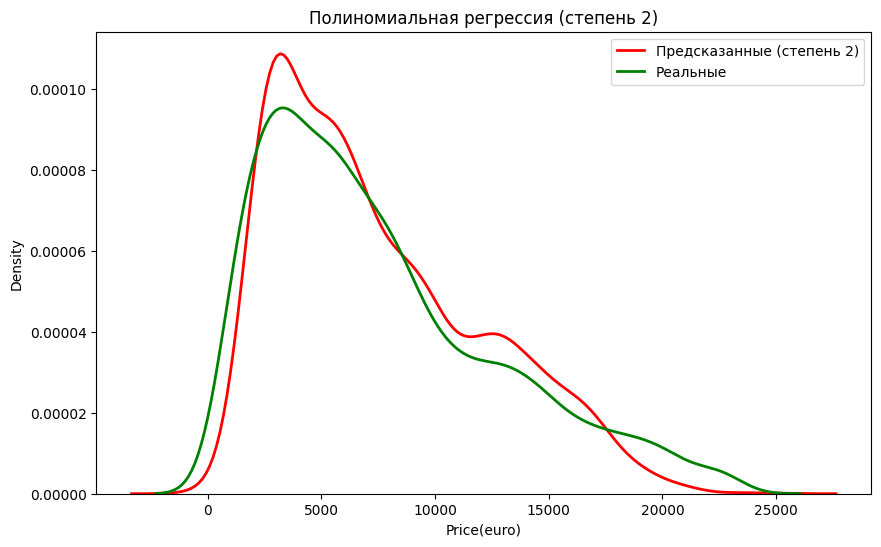


ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 3)
MAE: 1606.1632015034234
MSE: 5387128.318282346
RMSE: 2321.0188104111407
MAPE: 0.33399120187941955
R^2: 0.7983090057362072


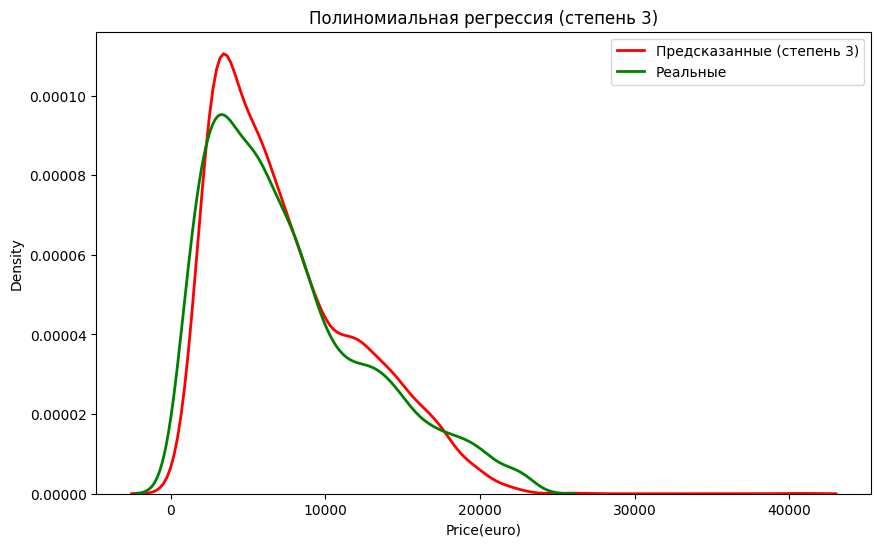


ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень 4)
MAE: 1523.3718653394371
MSE: 6800167.94489134
RMSE: 2607.713163845161
MAPE: 0.3361629418464909
R^2: 0.7454056126134355


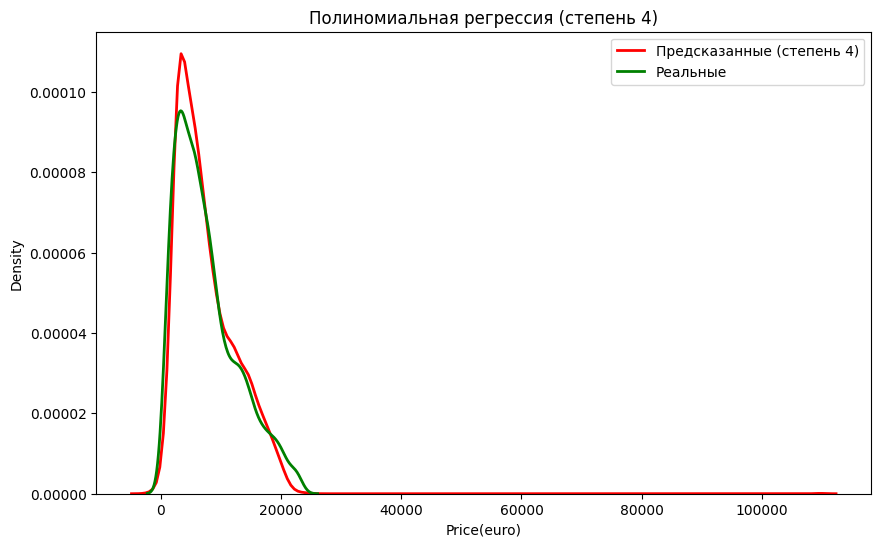

In [32]:
from sklearn.pipeline import Pipeline

degrees = [2, 3, 4]

for degree in degrees:
    print(f"\n{'='*50}")
    print(f"ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ (степень {degree})")
    print(f"{'='*50}")
    
    poly_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear_reg', LinearRegression())
    ])
    
    poly_pipeline.fit(X_train, y_train)
    y_pred_poly = poly_pipeline.predict(X_test)
    
    print(f'MAE: {mean_absolute_error(y_test, y_pred_poly)}')
    print(f'MSE: {mean_squared_error(y_test, y_pred_poly)}')
    print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_poly))}')
    print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_poly)}')
    print(f'R^2: {r2_score(y_test, y_pred_poly)}')
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(y_pred_poly, color='red', label=f'Предсказанные (степень {degree})', linewidth=2)
    sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
    plt.title(f'Полиномиальная регрессия (степень {degree})')
    plt.legend()
    plt.show()

## <a id='toc_5'></a>[5. Cобственные метрики](#toc_0)

In [33]:
def custom_r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def custom_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def custom_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def custom_rmse(y_true, y_pred):
    return np.sqrt(custom_mse(y_true, y_pred))

def custom_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [34]:
print("Сравнение метрик (полиномиальная регрессия, степень 2):")
print(f"R²: Scikit-learn - {r2_score(y_test, y_pred_p):.6f}, Custom - {custom_r2_score(y_test.values, y_pred_p):.6f}")
print(f"MAE: Scikit-learn - {mean_absolute_error(y_test, y_pred_p):.6f}, Custom - {custom_mae(y_test.values, y_pred_p):.6f}")
print(f"MSE: Scikit-learn - {mean_squared_error(y_test, y_pred_p):.6f}, Custom - {custom_mse(y_test.values, y_pred_p):.6f}")
print(f"RMSE: Scikit-learn - {sqrt(mean_squared_error(y_test, y_pred_p)):.6f}, Custom - {custom_rmse(y_test.values, y_pred_p):.6f}")

Сравнение метрик (полиномиальная регрессия, степень 2):
R²: Scikit-learn - 0.793931, Custom - 0.793931
MAE: Scikit-learn - 1674.169480, Custom - 1674.169480
MSE: Scikit-learn - 5504067.299728, Custom - 5504067.299728
RMSE: Scikit-learn - 2346.074871, Custom - 2346.074871


## <a id='toc_6'></a>[6. Вывод](#toc_0)

Наилучшие результаты показала полиномиальная регрессия 3-й степени с MAE = 1606 евро и R² = 0.798. Модель объясняет 80% дисперсии цен и ошибается в среднем на 1600 евро (MAPE = 33.4%).
Полиномиальная модель значительно превосходит линейные (R² = 0.681), что подтверждает нелинейный характер зависимостей между характеристиками автомобилей и их стоимостью.